# USD AAI-540 Group 1 — Warehouse explorer

Starter queries against the local DuckDB warehouse at `data/warehouse.duckdb`. Useful for partner walk-throughs and getting a feel for what's joinable.

**To run:** `make install-notebook && uv run --no-sync jupyter lab notebooks/explore.ipynb`

If `import eia` errors out, run `chflags nohidden .venv/lib/python*/site-packages/*.pth` first — macOS+iCloud hides editable-install pth files under Desktop paths.

In [1]:
import os
from pathlib import Path

# Run from the project root so settings find data/warehouse.duckdb
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import polars as pl
import matplotlib.pyplot as plt

from eia.warehouse import get_warehouse

wh = get_warehouse()
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

polars.config.Config

## 1. What's in the warehouse?

Every table with its row count and last-fetched time. Same content as `make warehouse-health` but inline.

In [2]:
tables = wh.query(
    "SELECT table_name FROM information_schema.tables "
    "WHERE table_schema = 'main' ORDER BY table_name"
)["table_name"].to_list()

rows = []
for t in tables:
    try:
        n = wh.query(f"SELECT COUNT(*) AS n FROM {t}").item()
    except Exception:
        n = None
    cols = wh.query(
        "SELECT COUNT(*) AS n FROM information_schema.columns "
        "WHERE table_schema = 'main' AND table_name = $name",
        params={"name": t},
    ).item()
    rows.append({"table": t, "rows": n, "cols": cols})

pl.DataFrame(rows).sort("rows", descending=True, nulls_last=True)

table,rows,cols
str,i64,i64
"""bls_qcew""",104075464,11
"""bea_io_make""",139941,5
"""bea_io_use""",139941,5
"""events""",49610,20
"""setlistfm_setlists""",49411,16
"""cdtfa_taxable_sales""",30624,12
"""tx_comptroller_county_allocati…",19944,14
"""census_state_tax_collections""",14217,9
"""dim_county""",3235,12


## 2. Federal feature data — sample each table

In [3]:
print('--- dim_county (TIGER) ---')
print(wh.query('SELECT county_fips, county_name, state_fips, latitude, longitude, land_area_sqmi FROM dim_county LIMIT 5'))

print('\n--- census_acs_county (ACS 5-yr) ---')
print(wh.query('SELECT * FROM census_acs_county LIMIT 5'))

--- dim_county (TIGER) ---
shape: (5, 6)
┌─────────────┬──────────────────┬────────────┬───────────┬─────────────┬────────────────┐
│ county_fips ┆ county_name      ┆ state_fips ┆ latitude  ┆ longitude   ┆ land_area_sqmi │
│ ---         ┆ ---              ┆ ---        ┆ ---       ┆ ---         ┆ ---            │
│ str         ┆ str              ┆ str        ┆ f64       ┆ f64         ┆ f64            │
╞═════════════╪══════════════════╪════════════╪═══════════╪═════════════╪════════════════╡
│ 31039       ┆ Cuming County    ┆ 31         ┆ 41.916312 ┆ -96.7874    ┆ 574.64958      │
│ 53069       ┆ Wahkiakum County ┆ 53         ┆ 46.291139 ┆ -123.433359 ┆ 286.698351     │
│ 35011       ┆ De Baca County   ┆ 35         ┆ 34.342297 ┆ -104.412089 ┆ 2334.338706    │
│ 31109       ┆ Lancaster County ┆ 31         ┆ 40.783894 ┆ -96.687757  ┆ 846.382301     │
│ 31129       ┆ Nuckolls County  ┆ 31         ┆ 40.176298 ┆ -98.047185  ┆ 575.818752     │
└─────────────┴──────────────────┴────────────┴──

In [4]:
print('--- bls_qcew (104M rows; sampling San Diego Q3 2023) ---')
print(wh.query("""
    SELECT county_fips, period_id, naics_code, ownership_code,
           avg_employment, total_wages_usd
    FROM bls_qcew
    WHERE county_fips = '06073' AND period_id = '2023Q3' AND ownership_code = 5
    ORDER BY avg_employment DESC LIMIT 10
"""))

--- bls_qcew (104M rows; sampling San Diego Q3 2023) ---
shape: (10, 6)
┌─────────────┬───────────┬────────────┬────────────────┬────────────────┬─────────────────┐
│ county_fips ┆ period_id ┆ naics_code ┆ ownership_code ┆ avg_employment ┆ total_wages_usd │
│ ---         ┆ ---       ┆ ---        ┆ ---            ┆ ---            ┆ ---             │
│ str         ┆ str       ┆ str        ┆ i16            ┆ i32            ┆ i64             │
╞═════════════╪═══════════╪════════════╪════════════════╪════════════════╪═════════════════╡
│ 06073       ┆ 2023Q3    ┆ 10         ┆ 5              ┆ 1295655        ┆ 23672264484     │
│ 06073       ┆ 2023Q3    ┆ 102        ┆ 5              ┆ 1080022        ┆ 18984438909     │
│ 06073       ┆ 2023Q3    ┆ 1024       ┆ 5              ┆ 268279         ┆ 6826189868      │
│ 06073       ┆ 2023Q3    ┆ 1025       ┆ 5              ┆ 237425         ┆ 3696995233      │
│ 06073       ┆ 2023Q3    ┆ 1021       ┆ 5              ┆ 220500         ┆ 3226192804      

In [5]:
print('--- bea_io_use (Use table 2023) ---')
print(wh.query("SELECT * FROM bea_io_use WHERE table_year = 2023 ORDER BY value_millions DESC NULLS LAST LIMIT 5"))

--- bea_io_use (Use table 2023) ---
shape: (5, 5)
┌────────────┬───────────────┬────────────────┬────────────────┬────────────────────────────┐
│ table_year ┆ industry_code ┆ commodity_code ┆ value_millions ┆ fetched_at                 │
│ ---        ┆ ---           ┆ ---            ┆ ---            ┆ ---                        │
│ i16        ┆ str           ┆ str            ┆ f64            ┆ datetime[μs]               │
╞════════════╪═══════════════╪════════════════╪════════════════╪════════════════════════════╡
│ 2023       ┆ 524           ┆ 524            ┆ 491631.0       ┆ 2026-05-10 02:32:24.326412 │
│ 2023       ┆ 324           ┆ 211            ┆ 384735.0       ┆ 2026-05-10 02:32:24.326412 │
│ 2023       ┆ 311FT         ┆ 111CA          ┆ 284299.0       ┆ 2026-05-10 02:32:24.326412 │
│ 2023       ┆ ORE           ┆ ORE            ┆ 233973.0       ┆ 2026-05-10 02:32:24.326412 │
│ 2023       ┆ 325           ┆ 325            ┆ 233261.0       ┆ 2026-05-10 02:32:24.326412 │
└─────────

## 3. Event data (X)

In [6]:
print('--- events (unified TM + Setlist.fm) ---')
print(wh.query('SELECT source, COUNT(*) FROM events GROUP BY source'))
print()
print(wh.query("""
    SELECT event_name, source, category, event_date, venue_name,
           venue_city, venue_state, county_fips, period_id
    FROM events
    WHERE county_fips = '06037'  -- Los Angeles
    LIMIT 5
"""))

--- events (unified TM + Setlist.fm) ---
shape: (2, 2)
┌──────────────┬──────────────┐
│ source       ┆ count_star() │
│ ---          ┆ ---          │
│ str          ┆ i64          │
╞══════════════╪══════════════╡
│ setlistfm    ┆ 49411        │
│ ticketmaster ┆ 199          │
└──────────────┴──────────────┘

shape: (5, 9)
┌──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ event_na ┆ source   ┆ category ┆ event_da ┆ venue_na ┆ venue_ci ┆ venue_st ┆ county_f ┆ period_i │
│ me       ┆ ---      ┆ ---      ┆ te       ┆ me       ┆ ty       ┆ ate      ┆ ips      ┆ d        │
│ ---      ┆ str      ┆ str      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str      ┆          ┆          ┆ str      ┆ str      ┆ str      ┆ str      ┆ str      ┆ str      │
╞══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╪══════════╡
│ Nervous  ┆ setlistf ┆ concert  ┆ 2022-12- ┆ Rubycon  ┆ Los      ┆ 

## 4. Y target data — three layers

In [7]:
print('--- Census STC: universal Y floor (all 50 + DC, annual) ---')
print(wh.query("""
    SELECT state_name, table_year,
           ROUND(amount_thousands_usd / 1e6, 1) AS general_sales_tax_billions
    FROM census_state_tax_collections
    WHERE item_code = 'T09' AND table_year = 2023
    ORDER BY amount_thousands_usd DESC NULLS LAST LIMIT 10
"""))

--- Census STC: universal Y floor (all 50 + DC, annual) ---
shape: (10, 3)
┌──────────────┬────────────┬────────────────────────────┐
│ state_name   ┆ table_year ┆ general_sales_tax_billions │
│ ---          ┆ ---        ┆ ---                        │
│ str          ┆ i16        ┆ f64                        │
╞══════════════╪════════════╪════════════════════════════╡
│ Texas        ┆ 2023       ┆ 53.7                       │
│ California   ┆ 2023       ┆ 53.6                       │
│ Florida      ┆ 2023       ┆ 40.0                       │
│ Washington   ┆ 2023       ┆ 22.8                       │
│ New York     ┆ 2023       ┆ 19.0                       │
│ Ohio         ┆ 2023       ┆ 16.5                       │
│ Illinois     ┆ 2023       ┆ 15.8                       │
│ Pennsylvania ┆ 2023       ┆ 15.4                       │
│ New Jersey   ┆ 2023       ┆ 14.7                       │
│ Tennessee    ┆ 2023       ┆ 13.8                       │
└──────────────┴────────────┴───────────

In [8]:
print('--- CDTFA: deep CA county x quarter x business type ---')
print(wh.query("""
    SELECT period_id, business_type,
           ROUND(taxable_sales_usd / 1e6, 1) AS millions_usd
    FROM cdtfa_taxable_sales
    WHERE county_fips = '06073' AND period_id = '2023Q3'
    ORDER BY taxable_sales_usd DESC NULLS LAST
"""))

--- CDTFA: deep CA county x quarter x business type ---
shape: (12, 3)
┌───────────┬─────────────────────────────────┬──────────────┐
│ period_id ┆ business_type                   ┆ millions_usd │
│ ---       ┆ ---                             ┆ ---          │
│ str       ┆ str                             ┆ f64          │
╞═══════════╪═════════════════════════════════╪══════════════╡
│ 2023Q3    ┆ Total All Outlets               ┆ 20555.3      │
│ 2023Q3    ┆ Total Retail and Food Services  ┆ 13939.8      │
│ 2023Q3    ┆ All Other Outlets               ┆ 6615.5       │
│ 2023Q3    ┆ Food Services and Drinking Pla… ┆ 2818.2       │
│ 2023Q3    ┆ Other Retail Group              ┆ 2528.0       │
│ 2023Q3    ┆ Motor Vehicle and Parts Dealer… ┆ 2266.2       │
│ 2023Q3    ┆ General Merchandise Stores      ┆ 1481.4       │
│ 2023Q3    ┆ Gasoline Stations               ┆ 1333.1       │
│ 2023Q3    ┆ Clothing and Clothing Accessor… ┆ 1128.6       │
│ 2023Q3    ┆ Building Material and Garden E… ┆

In [9]:
print('--- TX Comptroller: TX county x month sales tax allocations ---')
print(wh.query("""
    SELECT county_name, period_id,
           ROUND(net_payment_usd / 1e3, 1) AS allocation_thousands
    FROM tx_comptroller_county_allocations
    WHERE table_year = 2023 AND month = 7 AND county_fips IS NOT NULL
    ORDER BY net_payment_usd DESC LIMIT 10
"""))

--- TX Comptroller: TX county x month sales tax allocations ---
shape: (10, 3)
┌─────────────┬───────────┬──────────────────────┐
│ county_name ┆ period_id ┆ allocation_thousands │
│ ---         ┆ ---       ┆ ---                  │
│ str         ┆ str       ┆ f64                  │
╞═════════════╪═══════════╪══════════════════════╡
│ Midland     ┆ 2023-07   ┆ 6656.4               │
│ El Paso     ┆ 2023-07   ┆ 6107.9               │
│ Brazoria    ┆ 2023-07   ┆ 3223.5               │
│ Jefferson   ┆ 2023-07   ┆ 2942.2               │
│ Lubbock     ┆ 2023-07   ┆ 2912.9               │
│ Hays        ┆ 2023-07   ┆ 2766.4               │
│ Bell        ┆ 2023-07   ┆ 2724.8               │
│ Smith       ┆ 2023-07   ┆ 2362.5               │
│ Webb        ┆ 2023-07   ┆ 2341.1               │
│ McLennan    ┆ 2023-07   ┆ 2194.0               │
└─────────────┴───────────┴──────────────────────┘


## 5. The cross-source join — this is what the model actually trains on

For each (county, year) in California: number of events, accommodation employment, total taxable sales. Direct $X \to Y$ mapping.

In [10]:
ca_training_view = wh.query("""
    WITH ev AS (
        SELECT county_fips, COUNT(*) AS events
        FROM events
        WHERE source = 'setlistfm'
        GROUP BY county_fips
    ),
    cdtfa_2022 AS (
        SELECT county_fips,
               SUM(taxable_sales_usd) FILTER (WHERE business_type = 'Total All Outlets') AS total_y,
               SUM(taxable_sales_usd) FILTER (WHERE business_type = 'Food Services and Drinking Places') AS food_y
        FROM cdtfa_taxable_sales
        WHERE table_year = 2022
        GROUP BY county_fips
    ),
    acc AS (
        SELECT county_fips, SUM(avg_employment) AS accommodation_emp
        FROM bls_qcew
        WHERE period_id = '2023Q3' AND naics_code = '721' AND ownership_code = 5
        GROUP BY county_fips
    )
    SELECT
        d.county_name,
        a.population,
        ev.events AS setlistfm_events_2022,
        acc.accommodation_emp,
        ROUND(c.total_y / 1e9, 1) AS total_taxable_billions,
        ROUND(c.food_y / 1e9, 2) AS food_services_billions
    FROM dim_county d
    JOIN census_acs_county a USING (county_fips)
    JOIN cdtfa_2022 c USING (county_fips)
    LEFT JOIN ev USING (county_fips)
    LEFT JOIN acc USING (county_fips)
    WHERE d.state_fips = '06'
    ORDER BY total_y DESC NULLS LAST
    LIMIT 15
""")
ca_training_view

county_name,population,setlistfm_events_2022,accommodation_emp,total_taxable_billions,food_services_billions
str,i32,i64,"decimal[38,0]",f64,f64
"""Los Angeles County""",9848406,3710,46202,213.7,28.1
"""Orange County""",3164063,691,25712,88.0,10.25
"""San Diego County""",3282782,1197,30360,80.7,10.14
"""Riverside County""",2449909,154,12096,62.1,5.52
"""San Bernardino County""",2187816,219,4661,60.0,4.96
"""Santa Clara County""",1903297,254,7565,57.7,5.75
"""Alameda County""",1651949,672,5232,44.3,3.88
"""Sacramento County""",1584047,437,4600,36.5,3.39
"""Fresno County""",1012152,88,2236,24.3,1.98


## 6. A simple chart: CA county events vs. food-services taxable sales

Visually the relationship the Bayesian model will quantify.

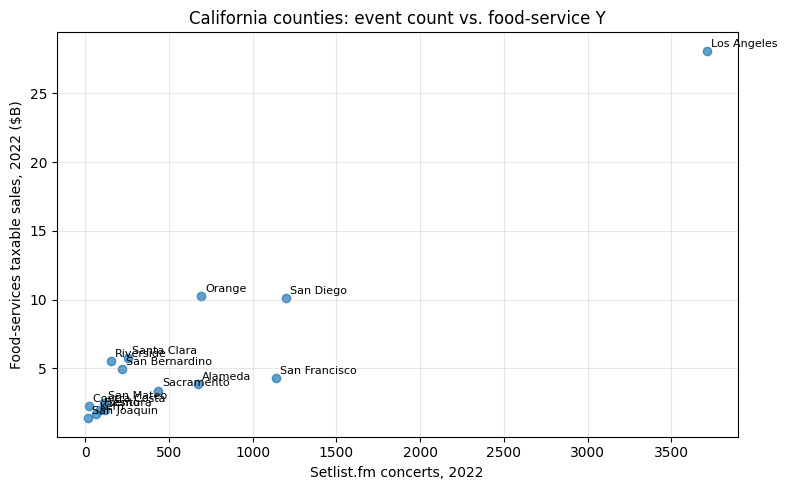

In [11]:
df = ca_training_view.drop_nulls(['setlistfm_events_2022', 'food_services_billions'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['setlistfm_events_2022'], df['food_services_billions'], alpha=0.7)
for row in df.iter_rows(named=True):
    ax.annotate(row['county_name'].replace(' County', ''),
                (row['setlistfm_events_2022'], row['food_services_billions']),
                fontsize=8, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Setlist.fm concerts, 2022')
ax.set_ylabel('Food-services taxable sales, 2022 ($B)')
ax.set_title('California counties: event count vs. food-service Y')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Multipliers — Leontief inverse for 2023

Diagonal of $L = (I - A)^{-1}$ is the total-output multiplier for each industry. Industries with bigger diagonal contribute more downstream economic activity per $1 of direct demand.

In [12]:
from eia.multipliers.leontief import compute_leontief_inverse

use = wh.query("SELECT industry_code, commodity_code, value_millions FROM bea_io_use WHERE table_year = 2023")
make = wh.query("SELECT industry_code, commodity_code, value_millions FROM bea_io_make WHERE table_year = 2023")
leontief = compute_leontief_inverse(use, make)

diagonals = leontief.filter(pl.col('output_industry') == pl.col('demand_industry'))
diagonals.sort('total_requirement', descending=True).head(10)

output_industry,demand_industry,total_requirement
str,str,f64
"""524""","""524""",1.560533
"""331""","""331""",1.453448
"""3361MV""","""3361MV""",1.407572
"""325""","""325""",1.330125
"""111CA""","""111CA""",1.313283
"""3364OT""","""3364OT""",1.295836
"""322""","""322""",1.287563
"""321""","""321""",1.260411
"""512""","""512""",1.228192


## 8. Where to go next

- `make build-events` to refresh the `events` table after a source pull
- `make phase1-summary` for the cross-source summary (CLI version of this notebook)
- `make validate-bea-multipliers` to confirm Leontief math against BEA's published CxI_DR
- Open issues for the model design: see [docs/MODEL_READINESS.md](../docs/MODEL_READINESS.md)